# Applied Exercise 7 - Random Forests on the Boston Data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [6]:
data = load_data("Boston")
X = data.drop(columns="medv")
y = data["medv"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
max_features_values = range(1, X.shape[1] + 1)
n_estimators_values = [50, 100, 200, 300, 500]

results = []
for n in n_estimators_values:
    for m in max_features_values:
        rf = RandomForestRegressor(n_estimators=n, max_features=m, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        predictions = rf.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        results.append([m, n, mse])

results = pd.DataFrame(results, columns=["max_features", "n_estimators", "Test_MSE"])

print("=" * 60)
print("RANDOM FOREST TEST ERRORS")
print("=" * 60)
print(results)

RANDOM FOREST TEST ERRORS
    max_features  n_estimators   Test_MSE
0              1            50  14.719937
1              2            50  11.629620
2              3            50  10.124335
3              4            50   9.728560
4              5            50   9.823222
5              6            50   9.350777
6              7            50   9.066230
7              8            50  10.321340
8              9            50   9.381376
9             10            50   8.949442
10            11            50   9.769647
11            12            50   9.349104
12             1           100  13.695061
13             2           100  11.430249
14             3           100   9.524454
15             4           100   9.408396
16             5           100   9.580961
17             6           100   8.939488
18             7           100   8.790998
19             8           100   9.358174
20             9           100   8.781779
21            10           100   8.502366
22      

BEST RANDOM FOREST
max_features = 12
n_estimators = 300
Test MSE = 8.3582


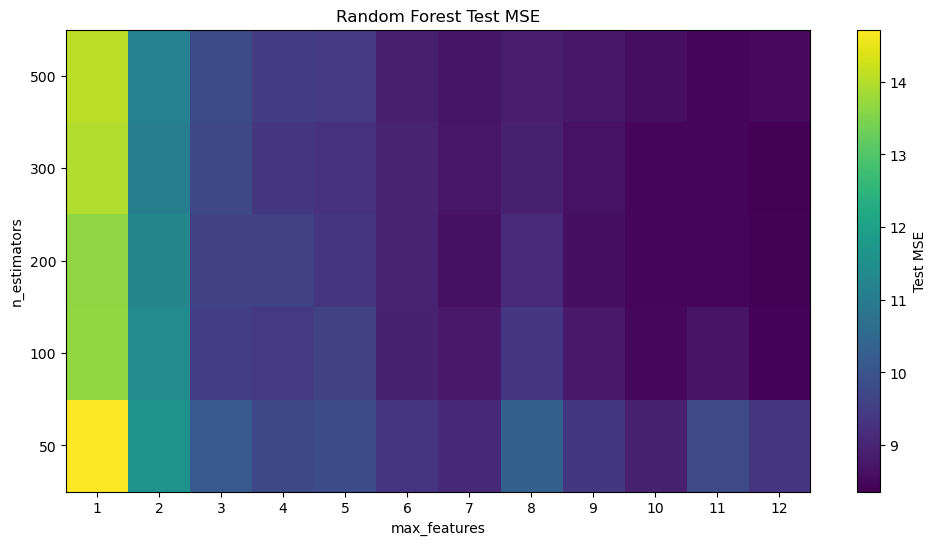

In [7]:
best = results.loc[results["Test_MSE"].idxmin()]

print("=" * 60)
print("BEST RANDOM FOREST")
print("=" * 60)
print(f"max_features = {int(best['max_features'])}")
print(f"n_estimators = {int(best['n_estimators'])}")
print(f"Test MSE = {best['Test_MSE']:.4f}")

plot_data = results.pivot(index="n_estimators", columns="max_features", values="Test_MSE")

plt.figure(figsize=(12, 6))
plt.imshow(plot_data, aspect="auto", origin="lower")
plt.colorbar(label="Test MSE")
plt.xticks(range(len(plot_data.columns)), plot_data.columns)
plt.yticks(range(len(plot_data.index)), plot_data.index)
plt.xlabel("max_features")
plt.ylabel("n_estimators")
plt.title("Random Forest Test MSE")
plt.show()

- With max_features = 1, the test MSE is quite high, around 13–14. As max_features increased, the test MSE generally decreased.
- The best performance occurs when max_features is close to the total number of predictors.
- Increasing n_estimators from 50 to 500 generally improves or stabilizes the results, although the improvement becomes relatively small after around 200–300 trees. The improvement from 300 to 500 trees is actually slightly worse at the best max_features, with 300 trees - 8.3582 and 500 trees - 8.5319.
- This illustrates that more trees do not necessarily give a lower test error for a particular random train/test split. Once there are enough trees, the random forest has largely stabilized.
- Depending on the business problem statement can number of trees be selected. If the requiement is a better model but can accept a complex model with more iterations, n = 300 can be selected. If the number of records is very high and trade-off of little variance for an efficient model can be accepted, n = 100 can be selected.